In [3]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

my_transform = transforms.Compose([
    transforms.Resize((32, 32)), # Changes 28x28 to 32x32
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1], std=[0.278]) # Scales 0 -> -0.35, 1 -> 3.2 (approximate to LeCun variance sampling)
])

train = MNIST(
    root='./data',
    train=True,
    transform = my_transform,
    download=True)

test = MNIST(
    root='./data',
    train=False,
    transform = my_transform,
    download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.64MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 259kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.82MB/s]


In [4]:
from torch.utils.data import DataLoader

trainloader = DataLoader(train, batch_size=64, shuffle=True)
testloader = DataLoader(test, batch_size=64, shuffle=False)

In [5]:
# images shape: [64, 1, 32, 32] -> 64 images, 1 channel (white-black), 32x32 pixels
# labels shape: [64]            -> 64 integers (0-9) 
train_features, train_labels = next(iter(trainloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 1, 32, 32])
Labels batch shape: torch.Size([64])


## Optional: For visualization of the first instances of the dataset(train)

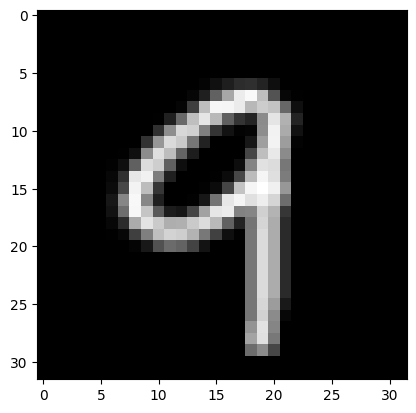

Label: 9


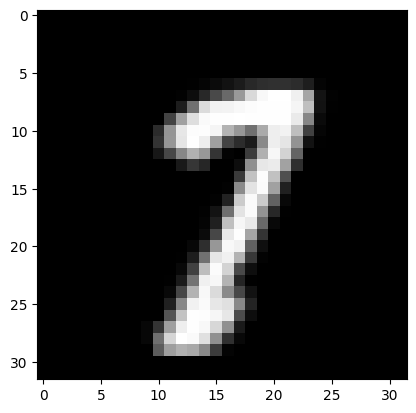

Label: 7


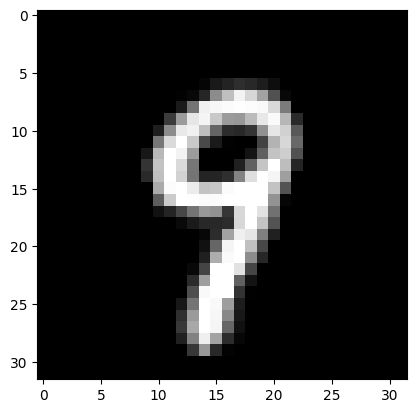

Label: 9


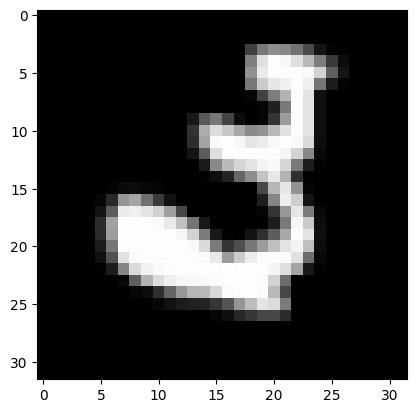

Label: 3


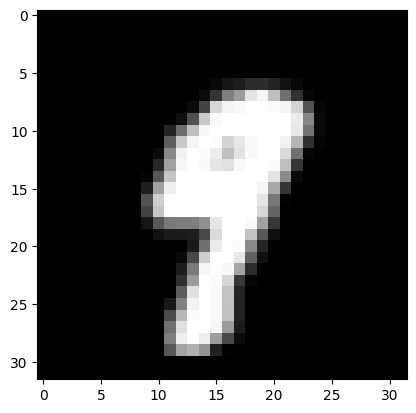

Label: 9


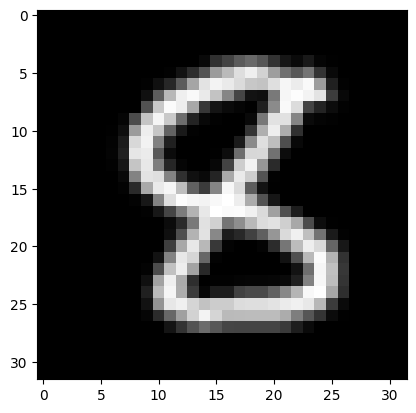

Label: 8


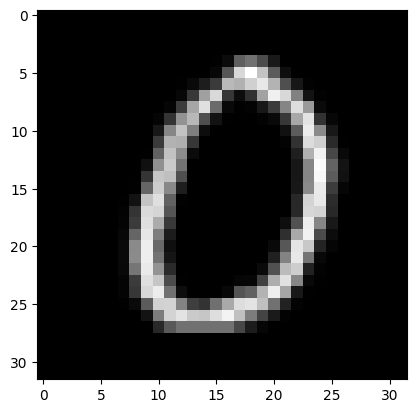

Label: 0


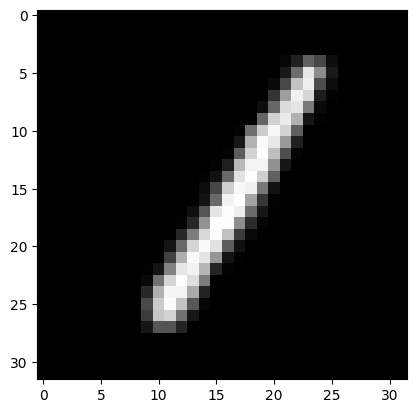

Label: 1


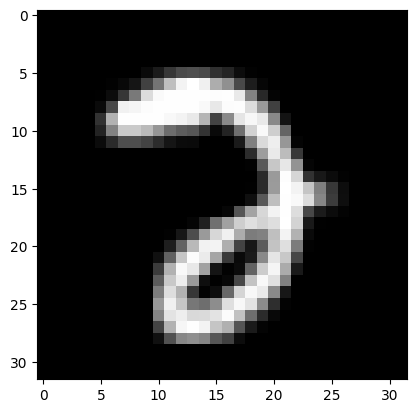

Label: 2


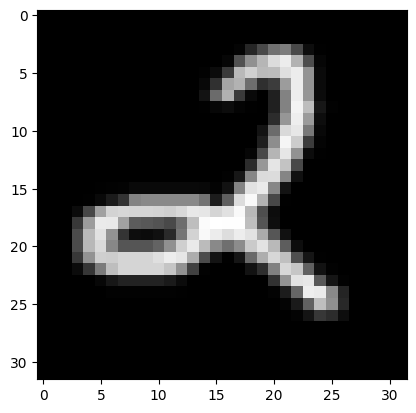

Label: 2


In [6]:
import matplotlib.pyplot as plt
for i in range(10):
    img = train_features[i].squeeze()
    label = train_labels[i]
    plt.imshow(img, cmap='gray')
    plt.show()
    print(f"Label: {label}")

In [9]:
"""Note: The following code snipped was ran on a CPU with a manual implementation of the training loop, but now the LeNet5_model class has an in-build method for that, namely fit(self, train_loader, epochs=15, lr=0.05)
"""
from src.model import LeNet_5
import torch
import torch.nn as nn
from torch.optim import SGD

EPOCHS = 15 * 3

model = LeNet_5()
optimizer = SGD(params=model.parameters(), lr=0.001)
# Custom loss implemented in the LeNet_5 paper - based on RBF (Radial Basis Function) that uses the distances between the output of the model and the target labels to compute the loss. The loss function encourages the model to produce outputs that are close to the correct class and far from the incorrect classes.
def lenet_rbf_loss(distances, target_labels):
    batch_size = distances.size(0)
    correct_class_distances = distances[torch.arange(batch_size), target_labels]
    # MAP penalty term - Maximum A Posteriori penalty term - mathematical formula added to the loss function to keep the model away from cheating (exploding the gradients).
    penalty = torch.logsumexp(-distances, dim=1)

    return torch.mean(correct_class_distances + penalty)

loss_l = []
for epoch in range(EPOCHS):
    print(f"Epoch: {epoch}")
    for batch_idx, (images, labels) in enumerate(trainloader):
        optimizer.zero_grad()
        
        outputs = model(images)

        loss = lenet_rbf_loss(outputs, labels)

        
        loss.backward()
        optimizer.step()

        loss_l.append(loss.item())
        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx} processed | Loss: {loss.item():3f}")

Epoch: 0
Batch 0 processed | Loss: 3.291315
Batch 100 processed | Loss: 0.689225
Batch 200 processed | Loss: 0.455538
Batch 300 processed | Loss: 0.572257
Batch 400 processed | Loss: 0.248251
Batch 500 processed | Loss: 0.226567
Batch 600 processed | Loss: 0.278571
Batch 700 processed | Loss: 0.387943
Batch 800 processed | Loss: 0.259373
Batch 900 processed | Loss: 0.410762
Epoch: 1
Batch 0 processed | Loss: 0.244519
Batch 100 processed | Loss: 0.224138
Batch 200 processed | Loss: 0.388573
Batch 300 processed | Loss: 0.287963
Batch 400 processed | Loss: 0.313888
Batch 500 processed | Loss: 0.237745
Batch 600 processed | Loss: 0.283674
Batch 700 processed | Loss: 0.168179
Batch 800 processed | Loss: 0.198045
Batch 900 processed | Loss: 0.309186
Epoch: 2
Batch 0 processed | Loss: 0.174097
Batch 100 processed | Loss: 0.226661
Batch 200 processed | Loss: 0.350422
Batch 300 processed | Loss: 0.254746
Batch 400 processed | Loss: 0.293148
Batch 500 processed | Loss: 0.304606
Batch 600 process

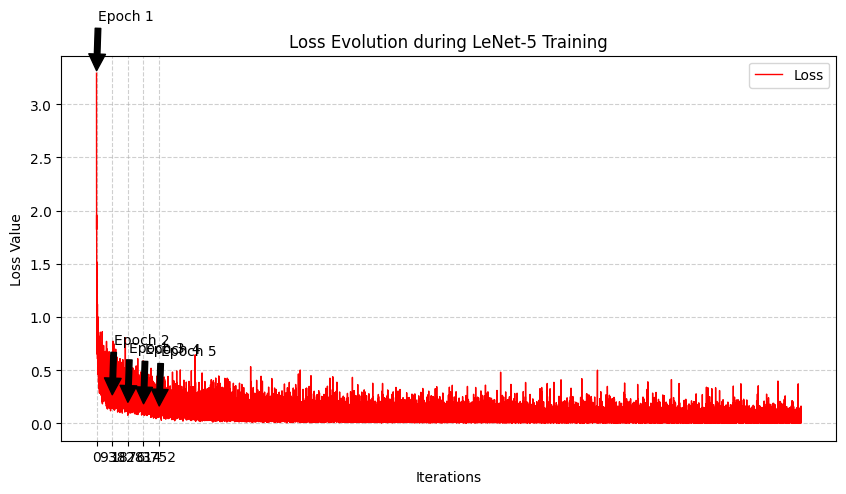

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_l, label="Loss", color='red', linewidth=1)

ax.set_title("Loss Evolution during LeNet-5 Training")
ax.set_xlabel("Iterations")
ax.set_ylabel("Loss Value")
ax.grid(True, linestyle='--', alpha=0.6)
ax.annotate('Epoch 1', xy=(0, loss_l[0]), xytext=(100, loss_l[0]+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('Epoch 2', xy=(len(trainloader), loss_l[len(trainloader)]), xytext=(len(trainloader)+100, loss_l[len(trainloader)]+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('Epoch 3', xy=(2*len(trainloader), loss_l[2*len(trainloader)]), xytext=(2*len(trainloader)+100, loss_l[2*len(trainloader)]+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('Epoch 4', xy=(3*len(trainloader), loss_l[3*len(trainloader)]), xytext=(3*len(trainloader)+100, loss_l[3*len(trainloader)]+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('Epoch 5', xy=(4*len(trainloader), loss_l[4*len(trainloader)]), xytext=(4*len(trainloader)+100, loss_l[4*len(trainloader)]+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.set_xticks([0, len(trainloader), 2*len(trainloader), 3*len(trainloader), 4*len(trainloader)])
ax.legend()

plt.show()

In [11]:
# Let's now evaluate the model on the test set to see how well it performs after training.
model.eval()  # Set the model to evaluation mode

correct = 0
total = 0
y_true = []
y_pred = []
with torch.no_grad():  # Disable gradient calculation for evaluation
    for images, labels in testloader:
        outputs = model(images)

        predicted = torch.argmin(outputs, dim=1) # Get the index of the minimum distance (predicted class) based on the custom RBF loss function (if we were to use CrossEntropyLoss, we would use torch.argmax instead)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of the model on the test set: {accuracy:.2f}% ( WOOOO HOOOOOOO )")

Accuracy of the model on the test set: 98.59% ( WOOOO HOOOOOOO )


In [12]:
predicted, labels

(tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6]),
 tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6]))

In [13]:
# Let's now save the model to a file so that we can load it later for inference or further training.
torch.save(model.state_dict(), "lenet5_model.pth")

# The Confusion Matrix

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [15]:
confusion_mat = confusion_matrix(y_true, y_pred)

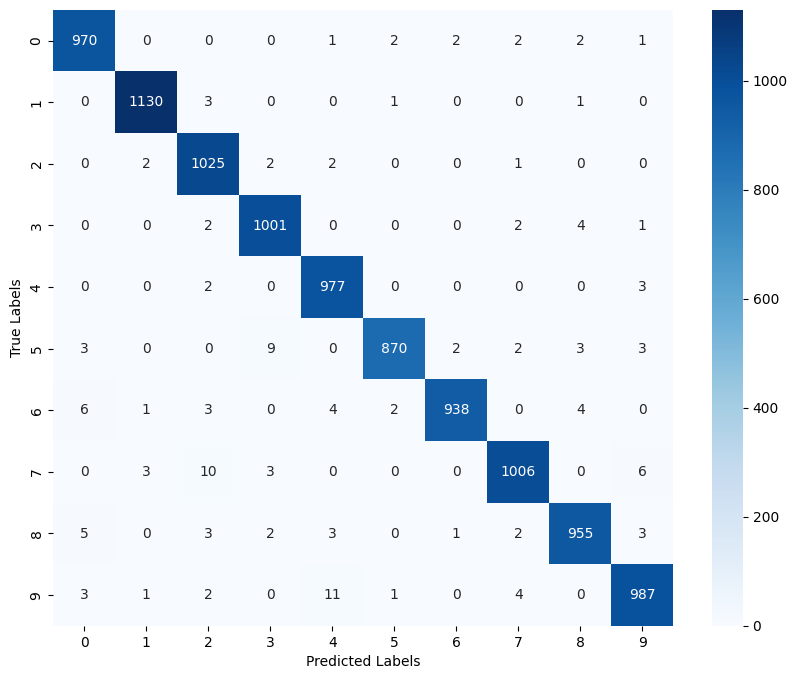

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report

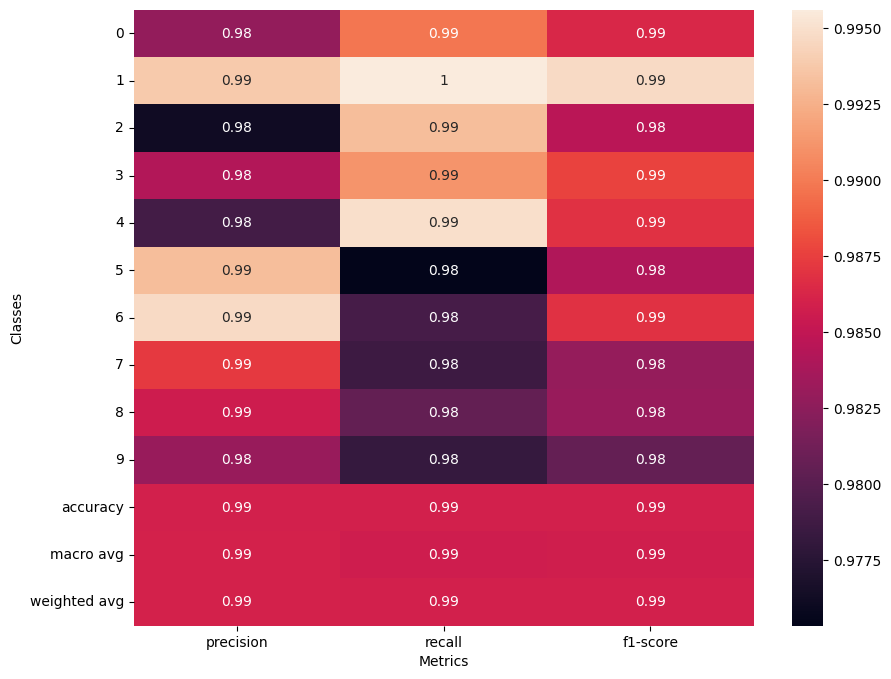

In [17]:
from sklearn.metrics import classification_report
import pandas as pd

cls_rep = classification_report(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).iloc[:-1, :].T, annot=True)
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.show()


# Now the live inference script

In [18]:
import random
 
def test_visual_predictions(model, test_loader, num_images=5, save_plt=None, seed=None):
    model.eval()  # Set the model to evaluation mode

    images, labels = next(iter(test_loader))  # Get a new batch of test images and labels

    if seed is not None:
        random.seed(seed)

    random_indices = random.sample(range(len(images)), num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 3.5, 4))

    if num_images == 1:
        axes = [axes]  # Ensure axes is iterable when num_images is 1

    with torch.no_grad():  # Disable gradient calculation for inference
        for i, idx in enumerate(random_indices):
            img = images[idx]
            label = labels[idx].item() # Get the true label as a Python integer

            # Add a new dimension to the image tensor to match the model's expected input shape
            img_batch = img.unsqueeze(0)  # Shape: [1, 1, 32, 32]

            outputs = model(img_batch)

            pred = torch.argmin(outputs, dim=1).item()  # Get the predicted class index

            rbf_distance = outputs[0][pred].item() # We extract the RBF distance for the predicted class

            """
            Now let's prepare the image for plotting
            In PyTorch the form is [Channels, Height, Width] but for matplotlib we need [Height, Width] for black-white images
            [1, 32, 32] -> [32, 32]
            """

            img_to_plot = img.squeeze().cpu().numpy()  # Convert to numpy array for plotting

            axes[i].imshow(img_to_plot, cmap='gray')

            color = 'green' if pred == label else 'red' # Color the title green if the prediction is correct, red otherwise

            axes[i].set_title(f"True: {label}\nPred: {pred}\nRBF Dist: {rbf_distance:.4f}", color=color)

            axes[i].axis('off')  # Hide the axes for better visualization

        plt.tight_layout()
        if save_plt == True: # Optional: If we want to save the plot as an image
                    plt.savefig("test_visual_predictions.png", bbox_inches='tight')
                    
        plt.show()

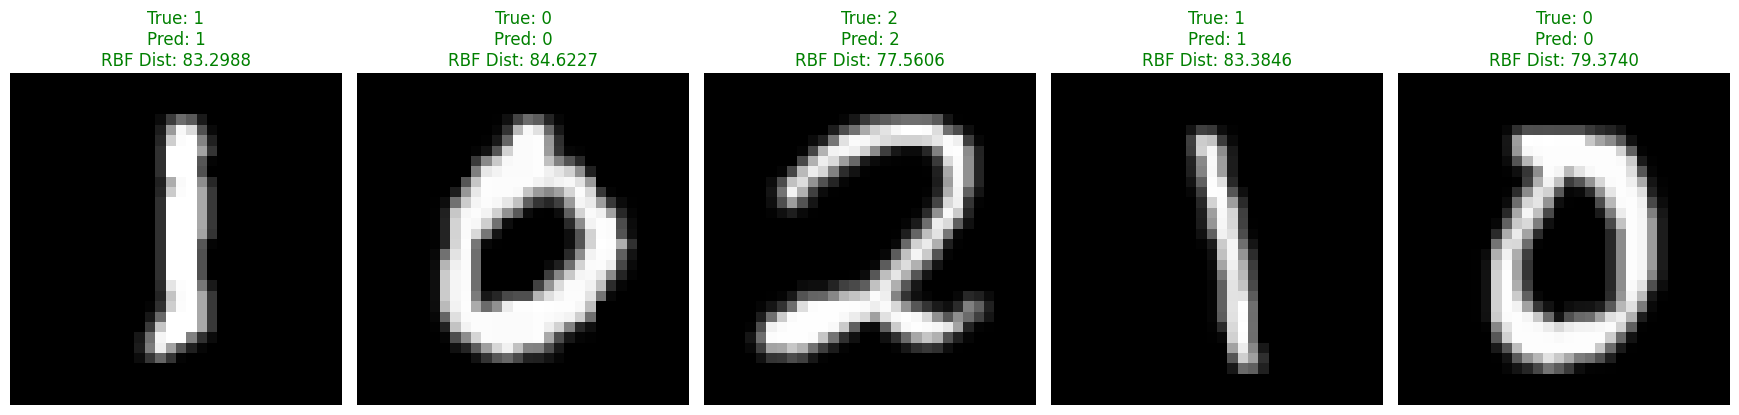

In [19]:
"""
The results are absolutely fascinating: 

The distances stabilize around ~130 instead of 0 due to two design features:
1. Scaled Tanh: Multiplying by 1.7159 expands differences exponentially when squared.
2. 120-D Sum: Summing minor errors across all 120 features naturally aggregates to ~130.

The tight distance range and perfect accuracy prove the model separated 
the classes cleanly; incorrect digits yield significantly larger distances. 
P.S: That if you sampled a batch of images that gave correct predictions of course :)
"""
test_visual_predictions(model, testloader, num_images=5, save_plt=True, seed=42)